In [ ]:
from data_preprocessing import load_and_process
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = load_and_process('dataset/green_tripdata_2021-01.parquet')
data.head()

,passenger_count,trip_distance,fare_amount,pickup_hour,pickup_day_of_week,tip_applied
0,1.0,1.01,5.5,0,4,0
1,1.0,2.53,10.0,0,4,1
2,1.0,1.12,6.0,0,4,1
3,1.0,1.99,8.0,23,3,0
7,6.0,0.45,3.5,0,4,1


In [3]:
data.describe()

,passenger_count,trip_distance,fare_amount,pickup_hour,pickup_day_of_week,tip_applied
count,37819.000000,37819.000000,37819.000000,37819.000000,37819.000000,37819.000000
mean,1.199318,3.283838,13.554802,13.773870,2.990137,0.500992
std,0.763019,3.850586,12.194310,4.650092,1.909775,0.500006
min,1.000000,0.010000,0.100000,0.000000,0.000000,0.000000
25%,1.000000,1.140000,6.500000,10.000000,1.000000,0.000000
50%,1.000000,1.900000,9.500000,14.000000,3.000000,1.000000
75%,1.000000,3.700000,15.500000,17.000000,5.000000,1.000000
max,6.000000,24.340000,268.000000,23.000000,6.000000,1.000000


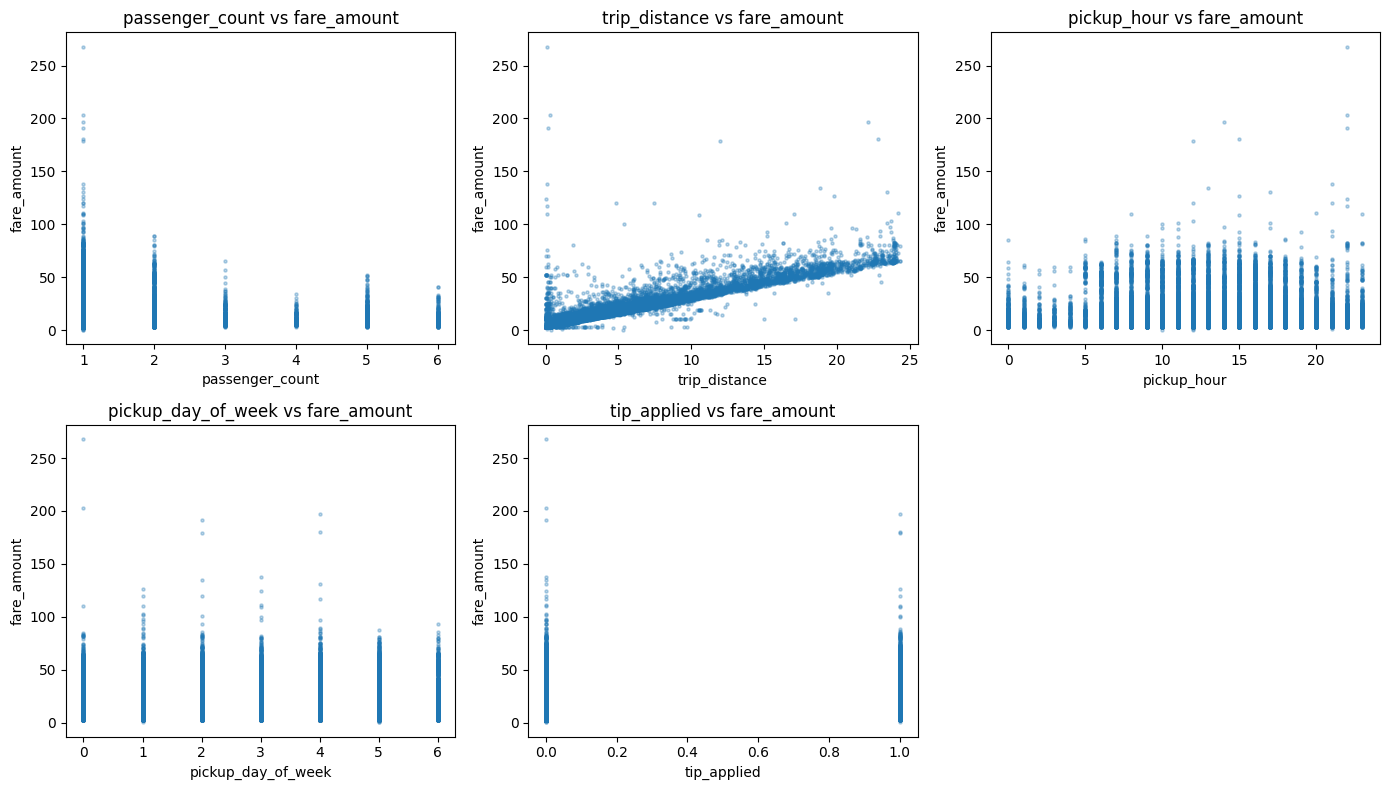

In [6]:
# Scatter plots: each feature vs fare_amount (fare_amount on y-axis)
features = ['passenger_count', 'trip_distance', 'pickup_hour', 'pickup_day_of_week', 'tip_applied']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, feat in enumerate(features):
    ax = axes.flat[idx]
    ax.scatter(data[feat], data['fare_amount'], alpha=0.3, s=5)
    ax.set_xlabel(feat)
    ax.set_ylabel('fare_amount')
    ax.set_title(f'{feat} vs fare_amount')

# Hide the last empty subplot (5 features in 2x3 grid)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

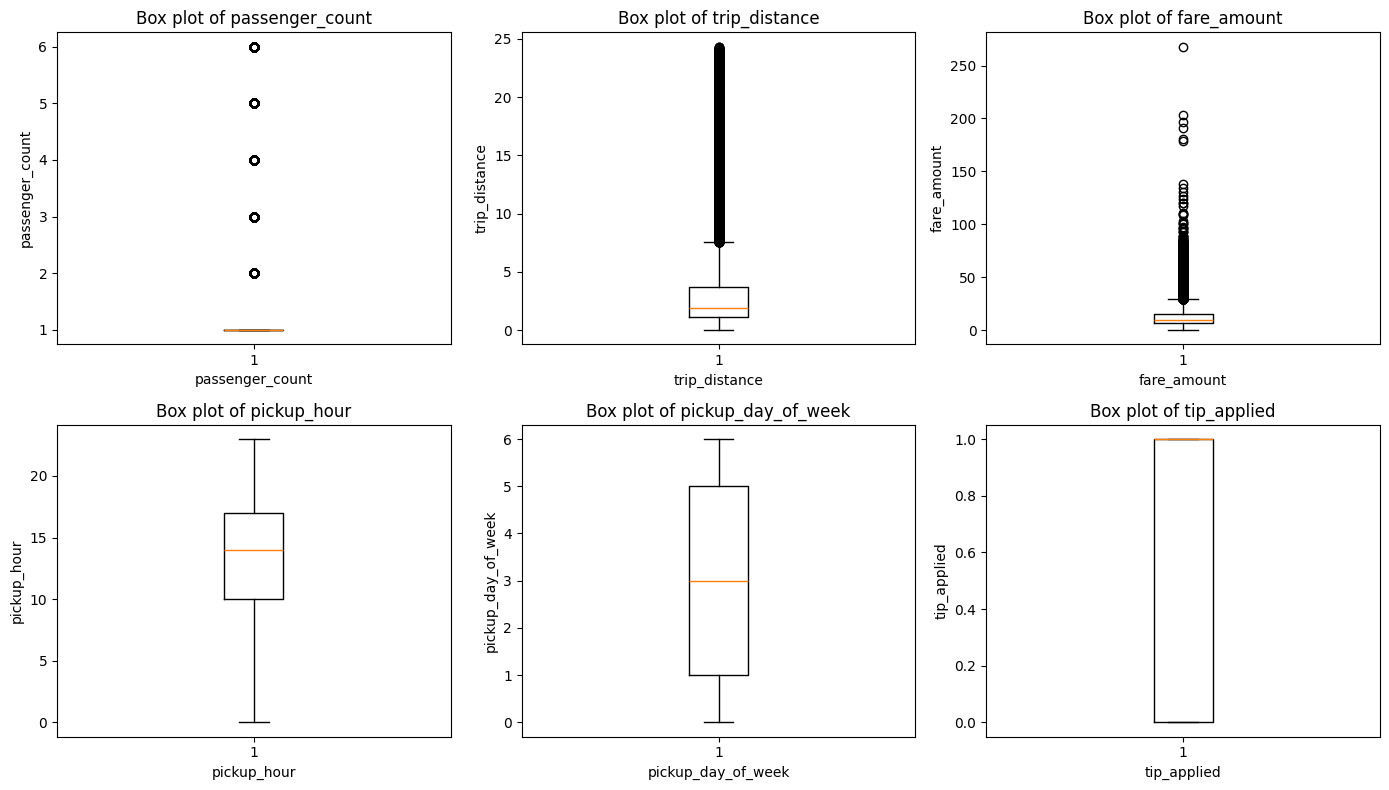

In [7]:
features = ['passenger_count', 'trip_distance', 'fare_amount', 'pickup_hour', 'pickup_day_of_week', 'tip_applied']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, feat in enumerate(features):
    ax = axes.flat[idx]
    ax.boxplot(data[feat].dropna(), vert=True)
    ax.set_xlabel(feat)
    ax.set_ylabel(feat)
    ax.set_title(f'Box plot of {feat}')

plt.tight_layout()
plt.show()

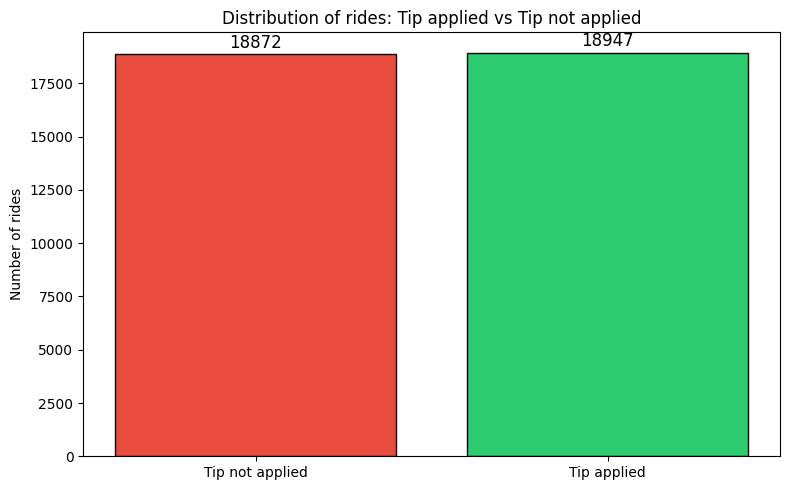

In [8]:
# Bar plot: distribution of rides - tip applied vs tip not applied
tip_counts = data['tip_applied'].value_counts().sort_index()
labels = ['Tip not applied', 'Tip applied']
colors = ['#e74c3c', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, tip_counts.values, color=colors, edgecolor='black')
plt.ylabel('Number of rides')
plt.title('Distribution of rides: Tip applied vs Tip not applied')
for bar, count in zip(bars, tip_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, str(count), ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

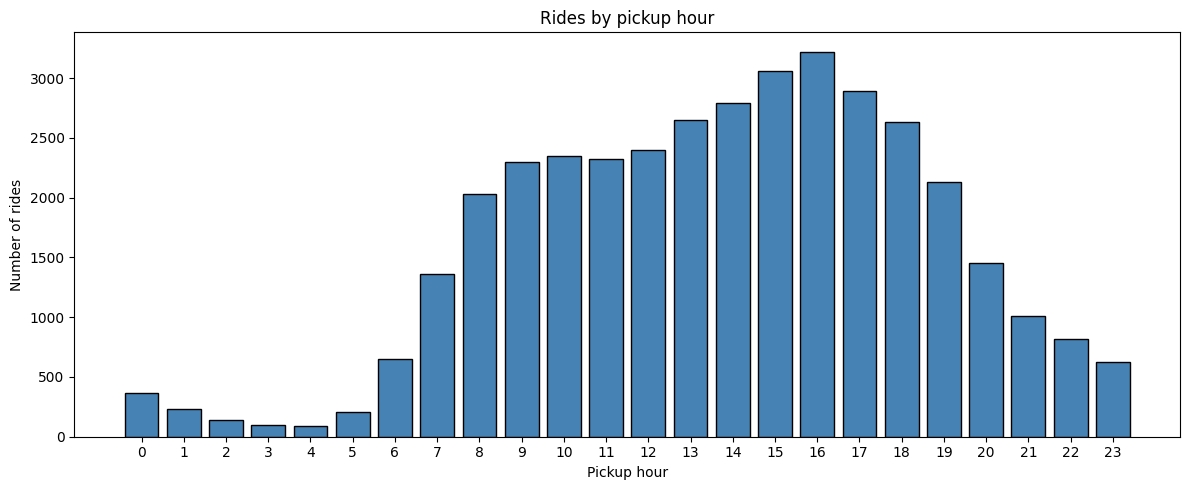

In [10]:
rides_by_hour = data['pickup_hour'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.bar(rides_by_hour.index, rides_by_hour.values, color='steelblue', edgecolor='black')
plt.xlabel('Pickup hour')
plt.ylabel('Number of rides')
plt.title('Rides by pickup hour')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

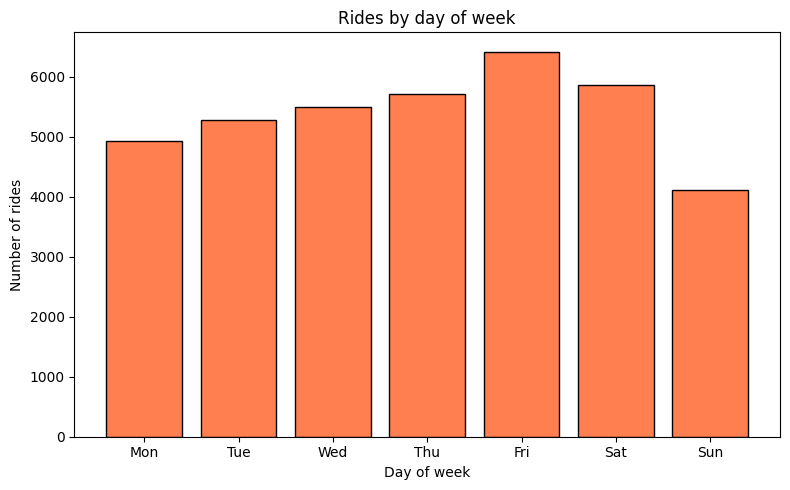

In [11]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
rides_by_day = data['pickup_day_of_week'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar([day_names[i] for i in rides_by_day.index], rides_by_day.values, color='coral', edgecolor='black')
plt.xlabel('Day of week')
plt.ylabel('Number of rides')
plt.title('Rides by day of week')
plt.tight_layout()
plt.show()

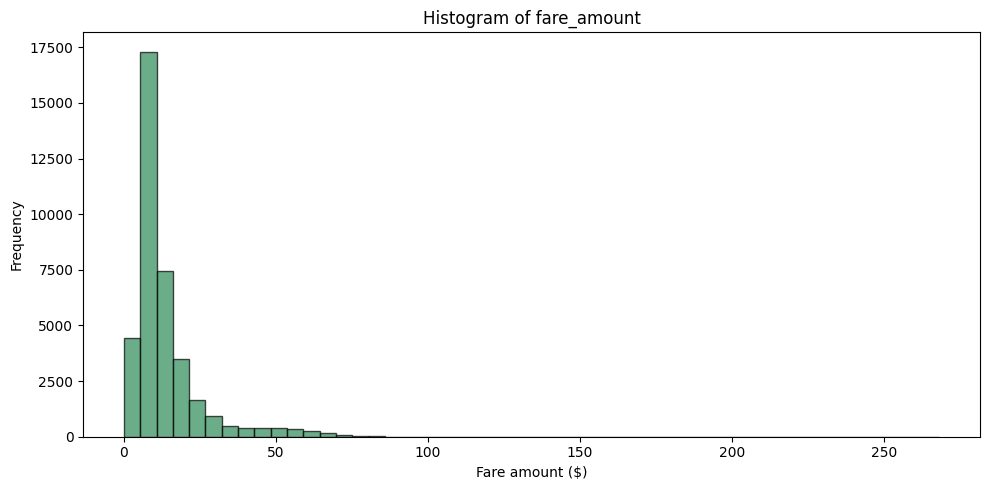

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(data['fare_amount'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
plt.xlabel('Fare amount ($)')
plt.ylabel('Frequency')
plt.title('Histogram of fare_amount')
plt.tight_layout()
plt.show()

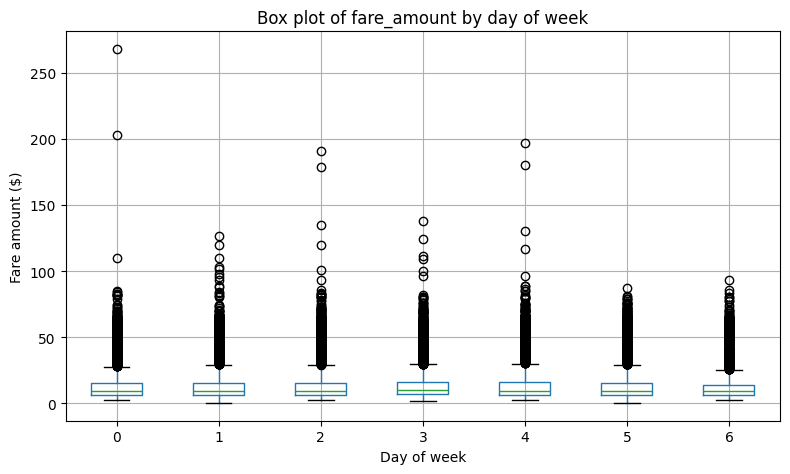

In [ ]:
plt.figure(figsize=(8, 5))
data.boxplot(column='fare_amount', by='pickup_day_of_week', ax=plt.gca())
plt.suptitle('')
plt.xlabel('Day of week')
plt.ylabel('Fare amount ($)')
plt.title('Box plot of fare_amount by day of week')
plt.tight_layout()
plt.show()

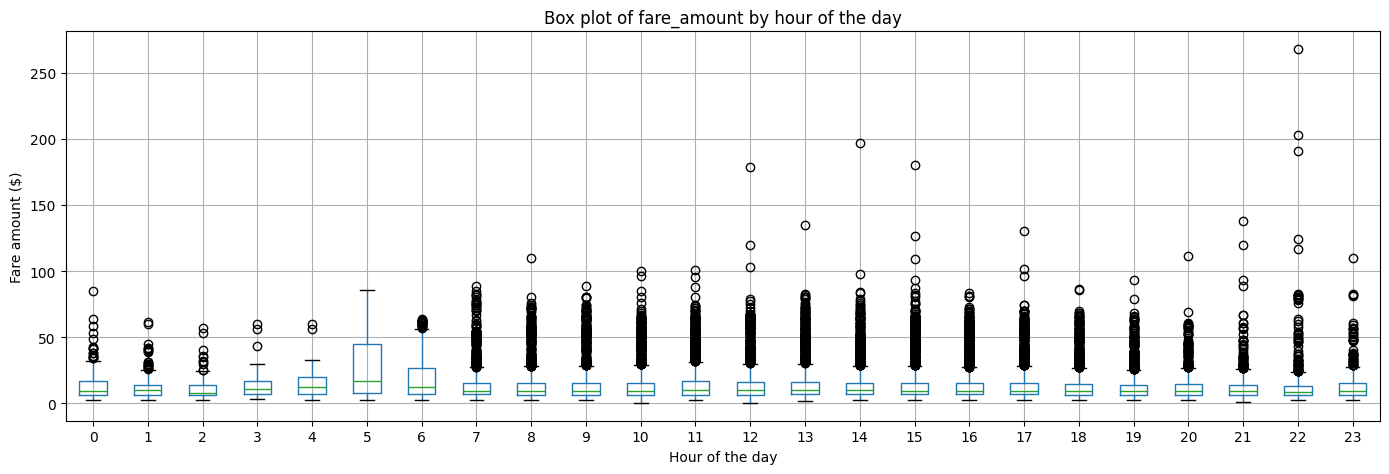

In [15]:
plt.figure(figsize=(14, 5))
data.boxplot(column='fare_amount', by='pickup_hour', ax=plt.gca())
plt.suptitle('')
plt.xlabel('Hour of the day')
plt.ylabel('Fare amount ($)')
plt.title('Box plot of fare_amount by hour of the day')
plt.tight_layout()
plt.show()